# Nguyễn Phúc Minh Châu - Lab 05

- Xây dựng mạng CNN với Keras để nhận dạng ký tự số viết tay.

- Sử dụng tập dữ liệu MNIST có sẵn trong Keras để train

In [ ]:
#import library

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# 1. Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [18]:
# 2. Preprocess the data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [19]:
# 3. Build the CNN model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 4. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model Summary:")
model.summary()

Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# 5. Train the model
history = model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.2, verbose=2)

Epoch 1/5
375/375 - 5s - 12ms/step - accuracy: 0.8916 - loss: 0.3539 - val_accuracy: 0.9768 - val_loss: 0.0799
Epoch 2/5
375/375 - 2s - 5ms/step - accuracy: 0.9668 - loss: 0.1103 - val_accuracy: 0.9845 - val_loss: 0.0549
Epoch 3/5
375/375 - 2s - 5ms/step - accuracy: 0.9760 - loss: 0.0800 - val_accuracy: 0.9851 - val_loss: 0.0528
Epoch 4/5
375/375 - 2s - 5ms/step - accuracy: 0.9801 - loss: 0.0648 - val_accuracy: 0.9871 - val_loss: 0.0421
Epoch 5/5
375/375 - 2s - 5ms/step - accuracy: 0.9836 - loss: 0.0551 - val_accuracy: 0.9886 - val_loss: 0.0406


Test accuracy: 0.9912, Test loss: 0.0291
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step


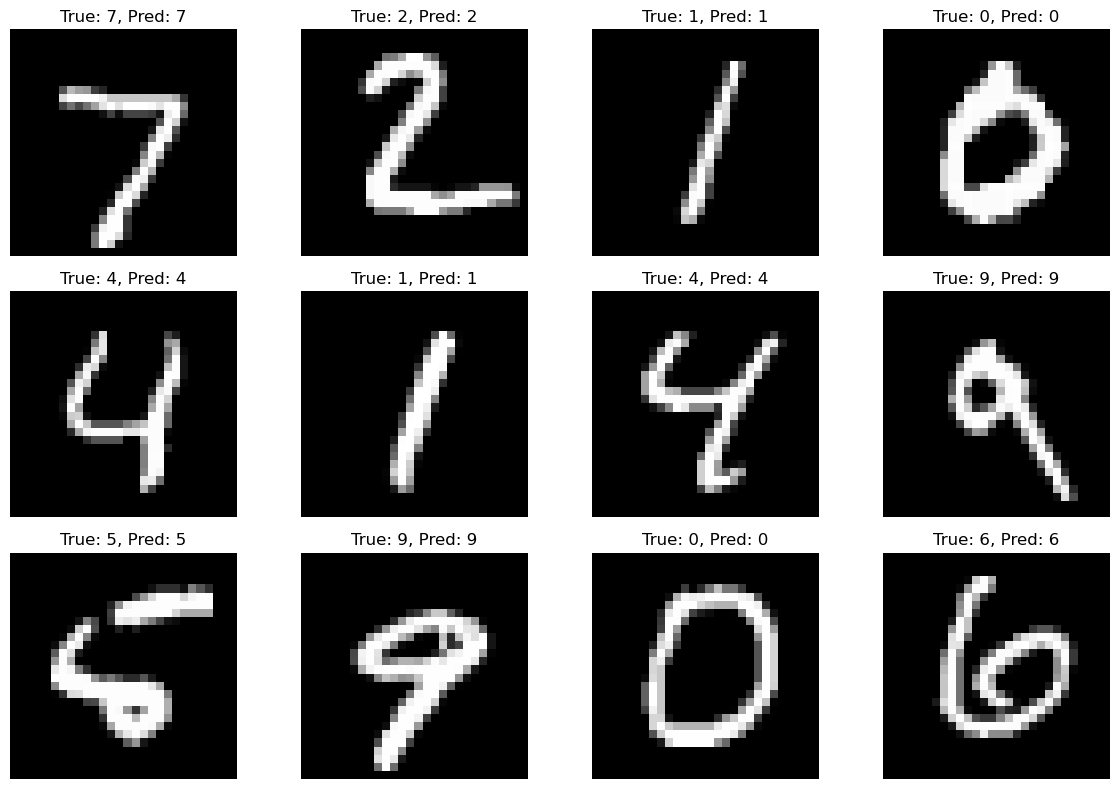

In [21]:
# 6. Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}')

# Show a few sample predictions
pred_probs = model.predict(x_test[:12])
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(y_test[:12], axis=1)

fig, axes = plt.subplots(3, 4, figsize=(12, 8))
axes = axes.ravel()
for i in range(12):
    axes[i].imshow(x_test[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'True: {true_labels[i]}, Pred: {pred_labels[i]}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

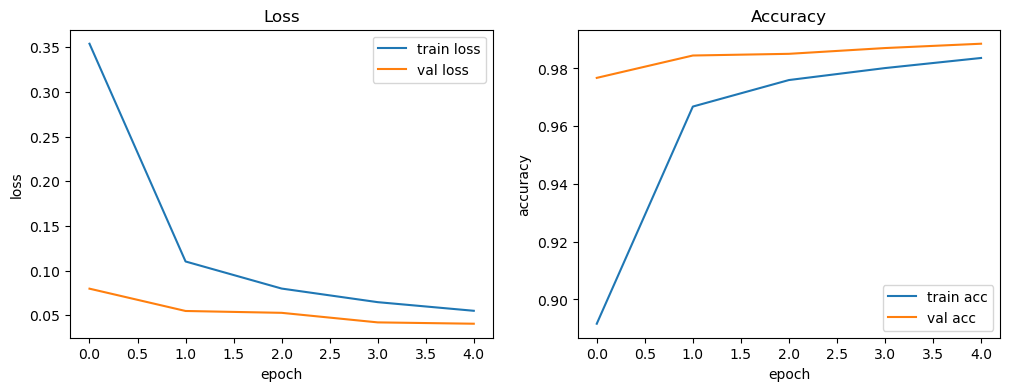

In [22]:
# 7. Plot training & validation accuracy and loss values
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(history.history['loss'], label='train loss')
ax[0].plot(history.history['val_loss'], label='val loss')
ax[0].set_title('Loss')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].legend()

ax[1].plot(history.history['accuracy'], label='train acc')
ax[1].plot(history.history['val_accuracy'], label='val acc')
ax[1].set_title('Accuracy')
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('accuracy')
ax[1].legend()

plt.show()